In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

data = pd.read_csv('../data/sp500_features.csv', index_col=0, parse_dates=True)
feature_cols = ['realized_volatility_5', 'realized_volatility_18', 'realized_volatility_21',
                'volume_ma_5', 'month']
x = data[feature_cols]
y = data['future_volatility_21']

split_idx = int(len(x) * 0.8)

x_train = x.iloc[:split_idx]
x_test = x.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [17]:
# Random forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=50)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random forest - RMSE: {rf_rmse:.4f}, MAE: {rf_mae:.4f}, R2: {rf_r2:.4f}")

Random forest - RMSE: 0.0915, MAE: 0.0517, R2: -0.4236


In [18]:
# XGBoost
xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=50)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost - RMSE: {xgb_rmse:.4f}, MAE: {xgb_mae:.4f}, R2: {xgb_r2:.4f}")

XGBoost - RMSE: 0.0951, MAE: 0.0544, R2: -0.5397


In [19]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

time_series_cross_validation = TimeSeriesSplit(n_splits = 5)

rf_cross_validation_scores = cross_val_score(rf_model, x, y, cv=time_series_cross_validation, scoring='neg_root_mean_squared_error')
xgb_cross_validation_score = cross_val_score(xgb_model, x, y, cv=time_series_cross_validation, scoring='neg_root_mean_squared_error')

print(f"Random Forest CV RMSE: {-rf_cross_validation_scores.mean():.4f} (+/- {rf_cross_validation_scores.std():.4f})")
print(f"XGBoost CV RMSE: {-xgb_cross_validation_score.mean():.4f} (+/- {xgb_cross_validation_score.std():.4f})")

Random Forest CV RMSE: 0.1005 (+/- 0.0482)
XGBoost CV RMSE: 0.1118 (+/- 0.0496)


In [20]:
results = pd.DataFrame({
    'Model': ['Naive Baseline', 'Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [0.0906, 0.0730, rf_rmse, xgb_rmse],
    'MAE': [0.0568, 0.0501, rf_mae, xgb_mae],
    'R2': [np.nan, 0.0924, rf_r2, xgb_r2]
})

print(results)

               Model      RMSE       MAE        R2
0     Naive Baseline  0.090600  0.056800       NaN
1  Linear Regression  0.073000  0.050100  0.092400
2      Random Forest  0.091458  0.051727 -0.423618
3            XGBoost  0.095114  0.054435 -0.539711


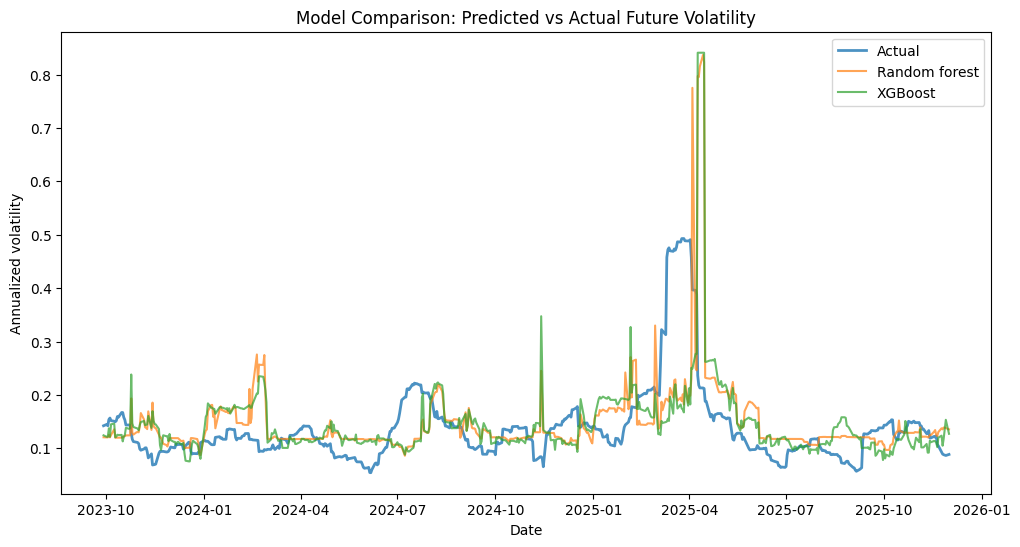

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual', alpha=0.8, linewidth=2)
plt.plot(y_test.index, rf_pred, label='Random forest', alpha=0.7)
plt.plot(y_test.index, xgb_pred, label='XGBoost', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Annualized volatility')
plt.title('Model Comparison: Predicted vs Actual Future Volatility')
plt.legend()
plt.show()

In [ ]:
## Summary

Trained Random Forest and XGBoost models to forecast 21-day future volatility, using the same
feature set and chronological split as Day 4, plus 5-fold time series cross-validation to test
robustness beyond a single train-test split.

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Naive Baseline | 0.0906 | 0.0568 | — |
| Linear Regression | 0.0730 | 0.0501 | 0.0924 |
| Random Forest | 0.0915 | 0.0517 | -0.4236 |
| XGBoost | 0.0951 | 0.0544 | -0.5397 |

**Cross-validation (5-fold, TimeSeriesSplit):**

| Model | CV RMSE (mean ± std) |
|---|---|
| Random Forest | 0.1005 ± 0.0482 |
| XGBoost | 0.1118 ± 0.0496 |

**Key finding:** Both tree-based models underperform not only Linear Regression but also the
naive baseline on RMSE, and both show *negative* R² on the test set — meaning they predict
worse than simply guessing the training mean. This is confirmed, not an artifact of one unlucky
split, by consistently poor cross-validation scores across 5 different time windows.

The most likely explanation is regime change: the test period (Sep 2023–Dec 2025) reflects
different volatility dynamics than the training period (2015–2023, which includes the 2020 COVID
shock). Tree-based models partition the feature space based on patterns learned in training and
struggle to extrapolate to a market regime with different volatility-feature relationships,
whereas linear regression's simpler, more constrained functional form generalizes more safely
here — despite the flexibility of trees usually being an advantage.

**Conclusion:** More model complexity does not help in this setting — a clear, honest result
that reinforces the broader theme of this project: financial markets are difficult to model,
and simpler linear approaches can outperform more sophisticated ones when the underlying
relationships are unstable over time. Linear Regression remains the best-performing model so
far and will be the baseline compared against the GARCH model in next day's analysis.